In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics.pairwise import cosine_distances
import tensorflow as tf # Added tensorflow import
from tensorflow import keras # Added keras import
from tensorflow.keras import layers # Added layers import

# ---------------------------------------------------------
# 1. Load Real Online Dataset (LFW)
# ---------------------------------------------------------
print("Downloading Labeled Faces in the Wild (LFW) dataset...")
# We only load people who have at least 2 images (so we can have an Anchor and a Positive)
lfw = fetch_lfw_people(min_faces_per_person=2, color=True)

images = lfw.images
labels = lfw.target
target_names = lfw.target_names

print(f"Loaded {len(images)} images of {len(target_names)} people.")

# ---------------------------------------------------------
# 2. Preprocess Images to 160x160 for FaceNet
# ---------------------------------------------------------
def preprocess_dataset(imgs):
    processed = []
    for img in imgs:
        # Resize to match our model's expected input
        resized = cv2.resize(img, (160, 160))
        # Ensure it is normalized between 0 and 1
        if resized.max() > 1.0:
            resized = resized / 255.0
        processed.append(resized)
    return np.array(processed, dtype='float32')

X_data = preprocess_dataset(images)

# ---------------------------------------------------------
# 3. Generate Real Triplets
# ---------------------------------------------------------
def generate_real_triplets(X, y, num_triplets=300):
    """Creates Anchor, Positive, and Negative sets from the LFW dataset."""
    anchors, positives, negatives = [], [], []
    unique_classes = np.unique(y)

    for _ in range(num_triplets):
        # 1. Pick a random person for Anchor & Positive
        pos_class = np.random.choice(unique_classes)
        pos_indices = np.where(y == pos_class)[0]

        # We need at least 2 images for this person
        if len(pos_indices) < 2:
            continue

        a_idx, p_idx = np.random.choice(pos_indices, 2, replace=False)

        # 2. Pick a DIFFERENT person for Negative
        neg_class = np.random.choice(np.setdiff1d(unique_classes, [pos_class]))
        neg_indices = np.where(y == neg_class)[0]
        n_idx = np.random.choice(neg_indices)

        anchors.append(X[a_idx])
        positives.append(X[p_idx])
        negatives.append(X[n_idx])

    return [np.array(anchors), np.array(positives), np.array(negatives)]

print("Creating training triplets...")
real_triplets = generate_real_triplets(X_data, labels, num_triplets=500)

# --- Start of fix ---

# ---------------------------------------------------------
# Define the Custom FaceNet Embedding Model (copied from other cells)
# ---------------------------------------------------------
def build_custom_facenet(input_shape=(160, 160, 3), embedding_size=128):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(64, (5,5), strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)

    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)

    x = layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)

    x = layers.Conv2D(512, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(embedding_size, activation=None)(x)
    embeddings = layers.Lambda(lambda tensor: tf.math.l2_normalize(tensor, axis=1))(x)

    return keras.Model(inputs, embeddings, name='Custom_FaceNet')

base_model = build_custom_facenet()


# ---------------------------------------------------------
# Define the Triplet Loss Function
# ---------------------------------------------------------
class TripletLoss(layers.Layer):
    def __init__(self, margin=0.2, **kwargs):
        super().__init__(**kwargs)
        self.margin = margin

    def call(self, anchor_embedding, positive_embedding, negative_embedding):
        ap_distance = tf.reduce_sum(tf.square(anchor_embedding - positive_embedding), axis=-1)
        an_distance = tf.reduce_sum(tf.square(anchor_embedding - negative_embedding), axis=-1)
        loss = tf.maximum(0.0, ap_distance - an_distance + self.margin)
        return loss

# ---------------------------------------------------------
# Define the Siamese Network Model for Training
# ---------------------------------------------------------
class SiameseModel(keras.Model):
    def __init__(self, embedding_model, margin=0.2):
        super().__init__()
        self.embedding_model = embedding_model
        self.triplet_loss_layer = TripletLoss(margin=margin)

    def call(self, inputs):
        anchor, positive, negative = inputs
        anchor_embedding = self.embedding_model(anchor)
        positive_embedding = self.embedding_model(positive)
        negative_embedding = self.embedding_model(negative)
        return (anchor_embedding, positive_embedding, negative_embedding)

    def train_step(self, data):
        # `data` is expected to be a tuple (x, y_dummy) where x is (anchor, positive, negative)
        if isinstance(data, tuple):
            x, _ = data # x contains (anchor, positive, negative), _ is the dummy y
        else:
            x = data # data is already (anchor, positive, negative) if y is not passed to fit

        with tf.GradientTape() as tape:
            anchor_embedding, positive_embedding, negative_embedding = self(x, training=True)
            loss = self.triplet_loss_layer(anchor_embedding, positive_embedding, negative_embedding)
            loss = tf.reduce_mean(loss) # Reduce to scalar

        gradients = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))

        # We don't have a direct metric for accuracy here,
        # but we can monitor the loss.
        return {"loss": loss}

# Instantiate the Siamese model
siamese_model = SiameseModel(embedding_model=base_model)
siamese_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001)) # Compile the model with an optimizer

# --- End of fix ---

# ---------------------------------------------------------
# 4. Train the Model
# ---------------------------------------------------------
print("Training Siamese Network on LFW Dataset...")
siamese_model.fit(
    x=real_triplets,
    y=np.zeros(len(real_triplets[0])), # Labels are 0 because loss is handled internally
    epochs=10,
    batch_size=16,
    verbose=1
)
print("Training Complete!")

Loaded 9164 images of 1680 people.
Creating training triplets...
Training Siamese Network on LFW Dataset...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'siamese_model_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


32/32 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - loss: 0.0000e+00
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - loss: 0.0000e+00
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - loss: 0.0000e+00
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - loss: 0.0000e+00
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - loss: 0.0000e+00
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - loss: 0.0000e+00
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - loss: 0.0000e+00
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - loss: 0.0000e+00
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - loss: 0.0000e+00
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - loss: 0.0000e+00
Training Complete!


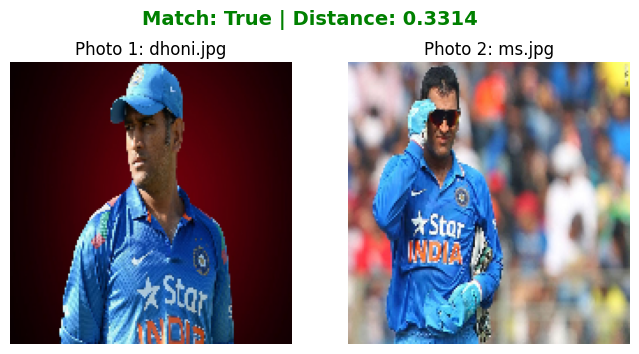

In [3]:
# ---------------------------------------------------------
# 5. Test 1:1 Verification Between Two Different Uploaded Photos
# ---------------------------------------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances

def preprocess_image(path):
    img_raw = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (160, 160))
    return img_resized.astype('float32') / 255.0

# 1. Load and Preprocess both uploaded photos
path1 = '/dhoni.jpeg'
path2 = '/ms.jpeg'

img_left = preprocess_image(path1)
img_right = preprocess_image(path2)

# 2. Extract 128-D embeddings using the base model
emb_left = base_model.predict(np.expand_dims(img_left, 0), verbose=0)[0]
emb_right = base_model.predict(np.expand_dims(img_right, 0), verbose=0)[0]

# 3. Calculate the distance between the two different photos
distance = cosine_distances([emb_left], [emb_right])[0][0]

# Determine if it's a match (threshold 0.5)
threshold = 0.5
is_match = distance < threshold

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_left)
axes[0].set_title("Photo 1: dhoni.jpg")
axes[0].axis('off')

axes[1].imshow(img_right)
axes[1].set_title("Photo 2: ms.jpg")
axes[1].axis('off')

plt.suptitle(f"Match: {is_match} | Distance: {distance:.4f}",
             color="green" if is_match else "red", fontsize=14, weight='bold')
plt.show()

OpenCV DNN found 8 face(s).


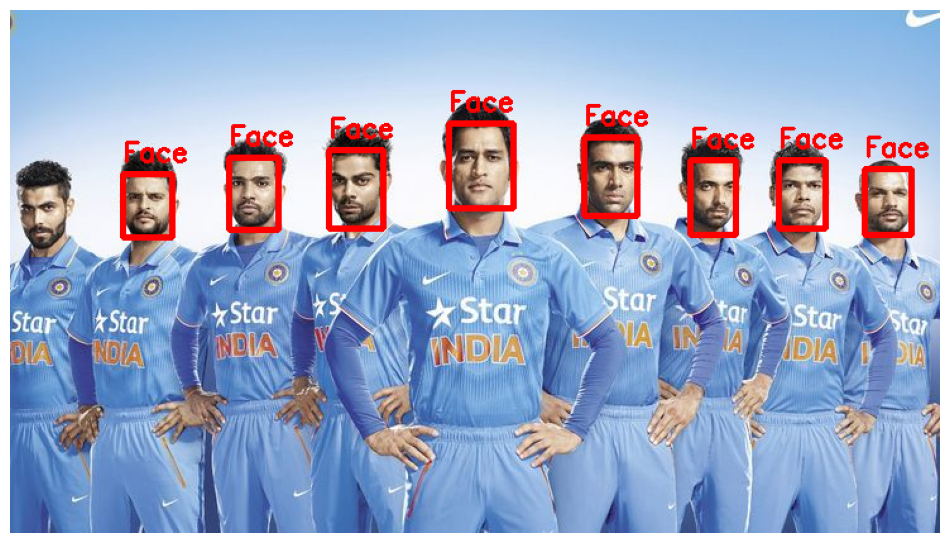

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances
import urllib.request
import os

# ---------------------------------------------------------
# 1. Auto-Download OpenCV's Deep Learning Face Detector
# ---------------------------------------------------------
prototxt_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"
model_url = "https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel"

prototxt_path = "deploy.prototxt"
model_path = "res10_300x300_ssd_iter_140000.caffemodel"

if not os.path.exists(prototxt_path):
    urllib.request.urlretrieve(prototxt_url, prototxt_path)
if not os.path.exists(model_path):
    urllib.request.urlretrieve(model_url, model_path)

dnn_net = cv2.dnn.readNetFromCaffe(prototxt_path, model_path)

def detect_faces_dnn(image_rgb, confidence_threshold=0.5):
    h, w = image_rgb.shape[:2]
    blob = cv2.dnn.blobFromImage(cv2.resize(image_rgb, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))
    dnn_net.setInput(blob)
    detections = dnn_net.forward()
    boxes = []
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > confidence_threshold:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")
            startX, startY = max(0, startX), max(0, startY)
            endX, endY = min(w, endX), min(h, endY)
            boxes.append((startX, startY, endX - startX, endY - startY))
    return boxes

def process_group_photo(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read {image_path}")
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    boxes = detect_faces_dnn(img_rgb)
    print(f"OpenCV DNN found {len(boxes)} face(s).")

    for (x, y, w, h) in boxes:
        # Draw boxes for all detected faces
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (255, 0, 0), 3)
        cv2.putText(img_rgb, "Face", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    # Process the group photo directly without registration
    process_group_photo("/group without reactions.jpeg")

Found 3 face(s). Analyzing emotions...


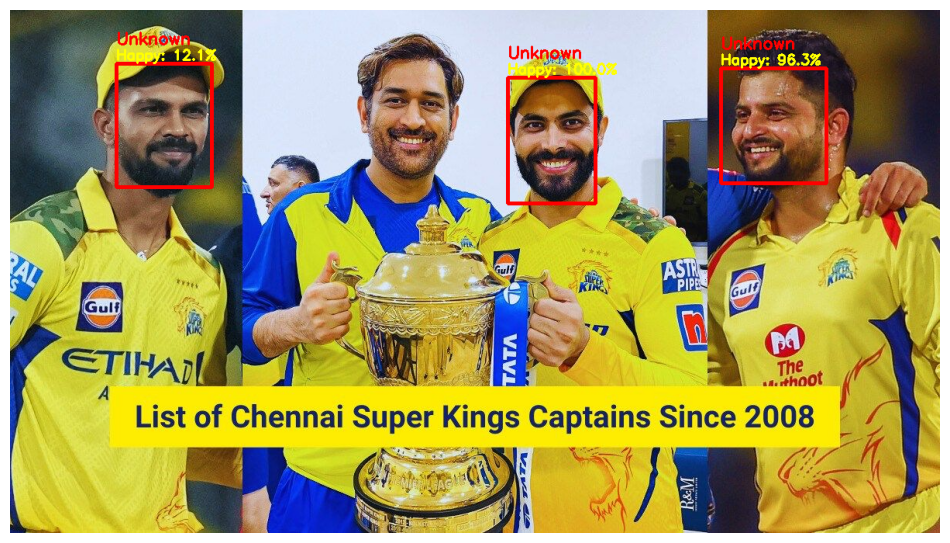

In [8]:
#!pip install deepface

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances
import urllib.request
import os

from deepface import DeepFace

# 1. OpenCV DNN Face Detector
prototxt_path = "deploy.prototxt"
model_path = "res10_300x300_ssd_iter_140000.caffemodel"
dnn_net = cv2.dnn.readNetFromCaffe(prototxt_path, model_path)

def detect_faces_dnn(image_rgb, confidence_threshold=0.5):
    h, w = image_rgb.shape[:2]
    blob = cv2.dnn.blobFromImage(cv2.resize(image_rgb, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))
    dnn_net.setInput(blob)
    detections = dnn_net.forward()
    boxes = []
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > confidence_threshold:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")
            startX, startY = max(0, startX), max(0, startY)
            endX, endY = min(w, endX), min(h, endY)
            boxes.append((startX, startY, endX - startX, endY - startY))
    return boxes

def build_custom_facenet(input_shape=(160, 160, 3), embedding_size=128):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(64, (5,5), strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Conv2D(512, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(embedding_size, activation=None)(x)
    embeddings = layers.Lambda(lambda tensor: tf.math.l2_normalize(tensor, axis=1))(x)
    return keras.Model(inputs, embeddings, name='Custom_FaceNet')

base_model = build_custom_facenet()
known_database = {}

def process_group_photo_with_emotions(image_path, threshold=0.5):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read {image_path}")
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    boxes = detect_faces_dnn(img_rgb)
    print(f"Found {len(boxes)} face(s). Analyzing emotions...")
    for (x, y, w, h) in boxes:
        margin = int(min(w, h) * 0.1)
        x1, y1 = max(0, x - margin), max(0, y - margin)
        x2, y2 = min(img_rgb.shape[1], x + w + margin), min(img_rgb.shape[0], y + h + margin)
        face_crop = img_rgb[y1:y2, x1:x2]
        if face_crop.size == 0: continue
        try:
            analysis = DeepFace.analyze(face_crop, actions=['emotion'], enforce_detection=False)
            if isinstance(analysis, list): analysis = analysis[0]
            happiness_score = analysis['emotion']['happy']
        except: happiness_score = 0.0
        face_resized = cv2.resize(face_crop, (160, 160))
        face_normalized = face_resized.astype('float32') / 255.0
        emb = base_model.predict(np.expand_dims(face_normalized, 0), verbose=0)[0]
        label = "Unknown"
        best_dist = float('inf')
        if known_database:
            distances = cosine_distances([emb], list(known_database.values()))[0]
            min_idx = np.argmin(distances)
            if distances[min_idx] < threshold:
                label = list(known_database.keys())[min_idx]
                best_dist = distances[min_idx]
        color = (0, 255, 0) if label != "Unknown" else (255, 0, 0)
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), color, 3)
        id_text = f"{label} ({best_dist:.2f})" if label != "Unknown" else label
        cv2.putText(img_rgb, id_text, (x, y-25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
        happy_text = f"Happy: {happiness_score:.1f}%"
        cv2.putText(img_rgb, happy_text, (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    known_database.clear()
    test_image = "/group 2.jpeg"
    process_group_photo_with_emotions(test_image, threshold=0.5)

Found 10 face(s). Analyzing emotions...


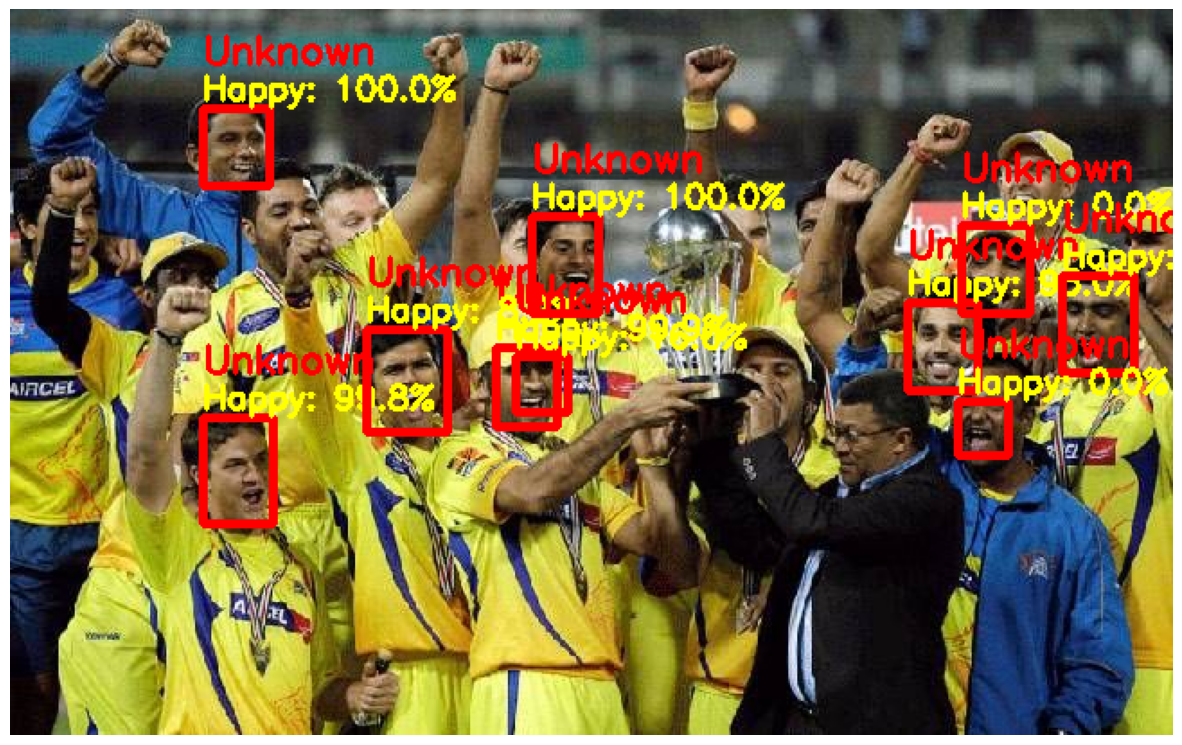

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances
import urllib.request
import os
from deepface import DeepFace

# 1. OpenCV DNN Face Detector
prototxt_path = "deploy.prototxt"
model_path = "res10_300x300_ssd_iter_140000.caffemodel"
dnn_net = cv2.dnn.readNetFromCaffe(prototxt_path, model_path)

def detect_faces_dnn(image_rgb, confidence_threshold=0.15):
    h, w = image_rgb.shape[:2]
    blob = cv2.dnn.blobFromImage(cv2.resize(image_rgb, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))
    dnn_net.setInput(blob)
    detections = dnn_net.forward()
    boxes = []
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > confidence_threshold:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")
            startX, startY = max(0, startX), max(0, startY)
            endX, endY = min(w, endX), min(h, endY)
            boxes.append((startX, startY, endX - startX, endY - startY))
    return boxes

def build_custom_facenet(input_shape=(160, 160, 3), embedding_size=128):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(64, (5,5), strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Conv2D(512, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(embedding_size, activation=None)(x)
    embeddings = layers.Lambda(lambda tensor: tf.math.l2_normalize(tensor, axis=1))(x)
    return keras.Model(inputs, embeddings, name='Custom_FaceNet')

base_model = build_custom_facenet()
known_database = {}

def process_group_photo_with_emotions(image_path, threshold=0.5):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read {image_path}. Please ensure the file is uploaded to the /content/ directory.")
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    boxes = detect_faces_dnn(img_rgb, confidence_threshold=0.15)
    print(f"Found {len(boxes)} face(s). Analyzing emotions...")
    for (x, y, w, h) in boxes:
        margin = int(min(w, h) * 0.1)
        x1, y1 = max(0, x - margin), max(0, y - margin)
        x2, y2 = min(img_rgb.shape[1], x + w + margin), min(img_rgb.shape[0], y + h + margin)
        face_crop = img_rgb[y1:y2, x1:x2]
        if face_crop.size == 0: continue
        try:
            analysis = DeepFace.analyze(face_crop, actions=['emotion'], enforce_detection=False)
            if isinstance(analysis, list): analysis = analysis[0]
            happiness_score = analysis['emotion']['happy']
        except: happiness_score = 0.0
        face_resized = cv2.resize(face_crop, (160, 160))
        face_normalized = face_resized.astype('float32') / 255.0
        emb = base_model.predict(np.expand_dims(face_normalized, 0), verbose=0)[0]
        label = "Unknown"
        best_dist = float('inf')
        if known_database:
            distances = cosine_distances([emb], list(known_database.values()))[0]
            min_idx = np.argmin(distances)
            if distances[min_idx] < threshold:
                label = list(known_database.keys())[min_idx]
                best_dist = distances[min_idx]
        color = (0, 255, 0) if label != "Unknown" else (255, 0, 0)
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), color, 3)
        id_text = f"{label} ({best_dist:.2f})" if label != "Unknown" else label
        cv2.putText(img_rgb, id_text, (x, y-25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
        happy_text = f"Happy: {happiness_score:.1f}%"
        cv2.putText(img_rgb, happy_text, (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
    plt.figure(figsize=(15, 10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    known_database.clear()
    # Processing the specific image requested
    test_image = "/group3.jpeg"
    process_group_photo_with_emotions(test_image, threshold=0.5)